# Analytic Skin Effect Transport Calculation Analysis
This notebook is for testing and analyzing the analytic Boltzmann transport calculations for a spherical Fermi surface.
The main purpose is to study how different material quantities (plasma frequency, scattering rate, Fermi velocity, etc.) influence the skin effect response of a material. In particular, how does the full broadband surface resistance response change as these material properties are changed?

Using the formulas from Hein et al., DOI:10.1103/PhysRevB.64.024529 (2001).

Also, using the formulas from Graham Baker's PhD dissertation (https://open.library.ubc.ca/soa/cIRcle/collections/ubctheses/24/items/1.0421263) (2022):
- The surface impedance integral for diffuse surface scattering, combined with the formulas from Hein et al.;
- The surface impedance formulas in the limits of different skin effect regimes;
- The formulas for the boundaries between different skin effect regimes.

Finally, this notebook also serves as an integration test for the above (specifically, comparing the full R_s response to the different asymptotic limits).

# Options

## Figure directory
Put all of the figures from this notebook into one folder, for organization purposes.

In [1]:
figure_folder_name = 'Analytic Transport Calculations'

## Figure options
Options for figures, to include extra information for processing and analysis, or not including it for final quality (eg. for thesis).

In [2]:
## Figure template name: select template to use
figure_template_name = 'DissertationTextwidthWide'
# figure_template_name = '2ColWide'

## Legend options
legend_include_run_name = True

## Save the figures, or just generate them?
save_figures = False


# Imports, Definitions and Plotting Details
Include imports for the libraries, otherwise the code editor will not see the libraries.
Define some things:
- useful units
- reference sample dimensions
- figure directory
- microwave data directory
- microwave catalogue
- sample catalogue

In [3]:
## %run Notebook-Boilerplate-General.ipynb

## General imports and definitions
To ensure that the code editor recognises the libraries, they must be imported here.

In [4]:
## Core
import numpy as np
import pandas as pd


## Various scipy libraries
from scipy import special
from scipy import constants
from scipy import stats
import scipy.integrate as integrate
from scipy.integrate import dblquad
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
import scipy.interpolate
from scipy.interpolate import interp1d

## Valuable constants
from scipy.constants import pi, hbar, physical_constants, mu_0, m_e, angstrom, electron_volt, elementary_charge, epsilon_0, c
ec = elementary_charge
ep_0 = epsilon_0

## System type libraries
import os
import sys
from time import time
import ast ## for string literal evaluation


## Matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as cm
from matplotlib.colors import ListedColormap
from matplotlib import rc
import matplotlib.ticker as mticker
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from mpl_toolkits import mplot3d

## Interactive widgets
import ipywidgets as widgets
from IPython.display import display

In [5]:
# Get the current working directory
current_directory = os.getcwd()

# Add the parent directory to the system path, for importing my own custom libraries
sys.path.append(os.path.dirname(current_directory))

### Common colours for plots

In [6]:
#TODO: replace these with the library functions
from Libraries import figure_helper as fh

tab10 = plt.get_cmap('tab10').colors
tab20 = plt.get_cmap('tab20').colors
viridis = mpl.colormaps['viridis']
cmap_reds = plt.get_cmap('Reds')
cmap_purples = plt.get_cmap('Purples')
cmap_blues = plt.get_cmap('Blues')

red_color = plt.get_cmap('tab10').colors[3]
light_red_color = plt.get_cmap('tab20').colors[7]
purple_color = plt.get_cmap('tab20').colors[8]
light_purple_color = plt.get_cmap('tab20').colors[9]

AgAu_color = fh.colour_AgAu

qmi_blue = (12/255, 35/255, 68/255)
qmi_red = (186/255, 0/255, 8/255)

def cmap_scale(sample_angle,cmap,max_angle=90,start_color=0.4,end_color=1.0):
    """Scale colormap based on sample angle."""
    start_color = 0.4
    end_color = 1.0
    color_value = (end_color-start_color)*(sample_angle)/(max_angle) + start_color
    # print(i,color_value, cmap(color_value))
    return cmap(color_value)[0:3]

# Define a custom formatting function
def axis_formatter_talk_freq(x, pos):
    """Format axis for frequency."""
    return f'{x:.0f}'

def axis_formatter_talk_Rs(x, pos):
    """Format axis for Rs."""
    return f'{x:.1f}'

## Specific imports
These are less often needed, so can usually be removed.

In [7]:
## Math
from mpmath import mp, fp

## Custom libraries
Import my custom libraries here.

In [8]:
## My libraries
from Libraries import broadband_tb as bb
from Libraries import crop_datafile as cd

from Libraries import conductivity_TB as con
from Libraries import impedance_TB as imp

from Libraries import sample_response as sr
from Libraries import fermi_surface_analytic as fs_analytic
from Libraries import numerical_fermi_surface_utilities as fs
from Libraries import electronic_transport as et

# from Libraries import reo3_tb_mattheiss as tb
# from reo3_conductivity_libraries import fermi_surface as fs
# from reo3_conductivity_libraries import impedance as imp

In [9]:
%load_ext autoreload
%autoreload 2

## Units and definitions
Define some helpful units and relevant quantities to use later.

In [10]:
## Define some units
nm = 1e-9
um = 1e-6
mm = 1e-3
GHz = 1e9
MHz = 1e6

uOhmcm = 1e-6*1e-2

Bohr_radius = constants.physical_constants['Bohr radius'][0]
eV_Angstrom_per_hbar = 151927 # eV * Angstrom / hbar = 151927 m/s
degree = pi/180
radians = 180/pi

Other specific definitions

In [11]:
## PdCoO2 properties
cond_Pd_300K = (2.6e-6*1e-2)**-1
cond_Pd_4K = (0.0075e-6*1e-2)**-1

## Reference AgAu properties
rho_AgAu = 5.28*1e-8  # Resistivity [Ohm m] # Source: Pat Turner's PhD thesis pg 22
u_rho_AgAu = 0.3*1e-8  # Resistivity [Ohm m] # Source: Pat Turner's PhD thesis pg 22

density_AgAu = 13.1363*1e-3/1e-2**3 #g/cm^3 Source: Kraut and Stern, Gold Bulletin 2000, 33(2) (2000). DOI: 10.1007/BF03216580

## ReO3 properties
## Unit cell information
a_ReO3 = 3.750*angstrom
BZ_edge = pi/a_ReO3 # edge of BZ for ReO3
scale_factor = (BZ_edge/1e10)/pi
print(BZ_edge/1e10)

0.8377580409572781


## Directories
Define directories
- Where to save the figures (correct path for different machines)
- Location of the cleaned, joined and cut microwave spectra
- Locations of the microwave run catalogue and the microwave sample catalogue

### Figure directory

In [12]:
## Figure information
current_directory = os.getcwd()
figure_relative_directory = 'Figures\\' + figure_folder_name + '\\'
parent_directory = os.path.dirname(current_directory)
figure_directory = os.path.join(parent_directory, figure_relative_directory)

print(parent_directory)
print(current_directory)
print(figure_directory)

## Template for saving figures:
# figure_filename = 'Indep_v_Freq-{}-0.svg'.format(run_name)
# figure_filepath = os.path.join(figure_directory, figure_filename)
# if save_figures: fh.save_svg(figure_filepath)

c:\Users\Tim\My Drive\Tim Work\Microwaves\Python
c:\Users\Tim\My Drive\Tim Work\Microwaves\Python\Jupyter Notebooks
c:\Users\Tim\My Drive\Tim Work\Microwaves\Python\Figures\Analytic Transport Calculations\


### Microwave data directories
For pre- and post-processed data sets.

In [13]:
averaged_spectra_directory = '../Microwave Data/Microwave Spectra (Individual)/'

joined_spectra_directory = '../Microwave Data/Microwave Spectra (Joined and Cut)/'

simulation_result_directory = '../Simulation Results/'

ReO3_DFT_FS_relative_directory = 'ReO3 DFT Fermi Surface Data\\'
mesh_relative_directory = 'Fermi Surface Mesh Data\\'

current_directory = os.getcwd()
parent_directory = os.path.dirname(current_directory)
figure_directory = os.path.join(parent_directory, figure_relative_directory)
ReO3_DFT_FS_directory = os.path.join(parent_directory, ReO3_DFT_FS_relative_directory)
mesh_directory = os.path.join(parent_directory, mesh_relative_directory)

## Microwave and sample catalogues
Load the microwave and sample catalogues.

In [14]:
# Load the microwave catalogue
filepath_microwave_catalogue = '../Microwave Data/Microwave Run Catalogue.xlsx'
filepath_sample_catalogue = '../Microwave Data/Microwave Sample Catalogue.xlsx'
microwave_catalogue = pd.read_excel(filepath_microwave_catalogue)
sample_catalogue = pd.read_excel(filepath_sample_catalogue)

microwave_runs = microwave_catalogue['Filename'].values

### Figure labels
Common figure labels generated as strings, for ease of use and consistency

In [15]:
## Common axis labels
label_f_GHz = r'Frequency (GHz)'
label_f_Hz = r'Frequency (Hz)'

label_Rs_Ohm = r'$R_s$ $\left(\Omega\right)$'
label_Rs_raw_Ohm = r'$R_s^{raw}$ $\left(\Omega\right)$'
label_Rs_mOhm = r'$R_s$ $\left(m\Omega\right)$'
label_Rs_raw_mOhm = r'$R_s^{raw}$ $\left(m\Omega\right)$'

label_Rs_Baker = r'$R_s/\sqrt{\mu_0 \omega}$ $\left(\sqrt{\mu\Omega\;cm}\right)$'
label_Rs_raw_Baker = r'$R_s^{raw}/\sqrt{\mu_0 \omega}$ $\left(\sqrt{\mu\Omega\;cm}\right)$'
label_Xs_Baker = r'$X_s/\sqrt{\mu_0 \omega}$ $\left(\sqrt{\mu\Omega\;cm}\right)$'

label_Zs_phase_rad = r'$\eta = \angle Z_s$ (rad)'
label_Zs_phase_deg = r'$\eta = \angle Z_s$ ($\deg$)'

label_Rs_ratio_raw_calc = r'$R_s^{raw}/R_s^{calc}$'

label_power_ratio = r'Power Ratio $P_s/P_r$'

label_delta_cl_m = r'$\delta_{cl}$ (m)'
label_delta_cl_um = r'$\delta_{cl}$ (um)'
label_delta_cl_nm = r'$\delta_{cl}$ (nm)'
label_delta_tilda_real_m = r'$2\operatorname{Re}(\tilde\delta)$ (m)'
label_delta_tilda_real_um = r'$2\operatorname{Re}(\tilde\delta)$ (um)'
label_delta_tilda_real_nm = r'$2\operatorname{Re}(\tilde\delta)$ (nm)'

Preamble version: 2025-01-23 Notebook updated 2025-01-23.

# Load the Fermi surface mesh data

In [16]:
# FS_models, FS_model_levels, FS_mesh_information, FS_mesh_data = fs.load_all_mesh_data(mesh_directory)
FS_models, FS_model_levels, FS_mesh_information, FS_mesh_filepaths, FS_face_data_filepaths = fs.load_all_mesh_information(mesh_directory)

def get_num_faces(mesh_name):
    """
    Get the number of faces in the mesh.

    Parameters
    ----------
    mesh_name : str
        The name of the mesh to get the number of faces for.

    Returns
    -------
    int
        The number of faces in the mesh.
    """
    return FS_mesh_information[mesh_name]['mesh_properties']['num_faces']

print(FS_models)
for levels, FS_model in FS_model_levels.items():
    print(levels, FS_model)
# print(FS_mesh_information)
# print(FS_model_levels['Sphere_Basic_01'])
# print(FS_mesh_filepaths)
# print(FS_mesh_data)


['ReO3_DFT_02_alpha-sheet', 'ReO3_DFT_02_beta-sheet', 'ReO3_DFT_02_gamma-sheet', 'ReO3_DFT_02', 'Sphere_Basic_01', 'Supersphere_Basic_Exponent-2.0_01', 'Supersphere_Basic_Exponent-3.0_01', 'Supersphere_Basic_Exponent-4.0_01', 'Supersphere_Basic_Exponent-8.0_01']
ReO3_DFT_02_alpha-sheet ['2', '4', '4_wannierized', '5_wannierized']
ReO3_DFT_02_beta-sheet ['2', '4', '4_wannierized', '5_wannierized']
ReO3_DFT_02_gamma-sheet ['2', '4', '4_wannierized', '5_wannierized']
ReO3_DFT_02 ['2', '4', '4_wannierized', '5_wannierized']
Sphere_Basic_01 ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
Supersphere_Basic_Exponent-2.0_01 ['0', '1', '2', '3', '4', '5', '6', '7', '8']
Supersphere_Basic_Exponent-3.0_01 ['0', '1', '2', '3', '4', '5', '6', '7', '8']
Supersphere_Basic_Exponent-4.0_01 ['0', '1', '2', '3', '4', '5', '6', '7', '8']
Supersphere_Basic_Exponent-8.0_01 ['0', '1', '2', '3', '4', '5', '6', '7', '8']


# Select which Fermi surface model to investigate
This is simply for the calculation parameters in this notebook, and the mesh data are not used.

In [17]:
# import ipywidgets as widgets
# from IPython.display import display

selected_FS_model = 'Sphere_Basic_01'

def levels_list_to_str(levels_list):
    return ', '.join([str(level) for level in levels_list])

# Create a dropdown menu for FS-model keys and list of the available levels
fs_model_options = [(f"{model} (Levels: {levels_list_to_str(FS_model_levels[model])})", model) for model in FS_models]

fs_model_dropdown = widgets.Select(
    options=fs_model_options,
    value=fs_model_options[0][1],  # Set default value to the first item in the options list
    description='FS Model:',
    disabled=False,
    layout=widgets.Layout(width='70%', height='300px'),  # Adjusting the size of the dropdown
    style={'button_color': 'lightblue'}  # Highlight selected option with light blue color
)

# Function to handle changes in the FS-model dropdown
def on_fs_model_change(change):
    global selected_FS_model  # Declare FS_model as global
    if change['type'] == 'change' and change['name'] == 'value':
        # Save the selected FS-model
        selected_FS_model = change['new']
        print(f"Selected FS Model: {selected_FS_model}")
        # Update the dropdown menu to reflect the current selection
        fs_model_dropdown.value = selected_FS_model

# Observe the FS-model dropdown for changes
fs_model_dropdown.observe(on_fs_model_change, names='value')

# Display the FS-model dropdown
display(fs_model_dropdown)

print(selected_FS_model)


Select(description='FS Model:', layout=Layout(height='300px', width='70%'), options=(('ReO3_DFT_02_alpha-sheet…

Sphere_Basic_01


Selected FS Model: Sphere_Basic_01


In [18]:
%%run false

UsageError: Cell magic `%%run` not found (But line magic `%run` exists, did you mean that instead?).


## Load the selected model data

In [19]:
FS_model = selected_FS_model
FS_levels = FS_model_levels[FS_model]
# selected_FS_level = int(FS_levels[-1])
selected_FS_level = max(FS_levels)

selected_FS_names = {level: fs.FS_mesh_name(selected_FS_model, level) for level in [selected_FS_level]}
print(selected_FS_names)
selected_FS_filepaths = {mesh_name: FS_face_data_filepaths[mesh_name] for level, mesh_name in selected_FS_names.items()}
# print(selected_FS_filepaths)

{'9': 'Sphere_Basic_01_Level-9'}


## ReO3 transport values (full Fermi Surface)

In [20]:
m_eff_ReO3_sheets = m_e*np.array([0.42, 0.54, 0.45]) ## From Chen et al. (2001), DOI: 10.1103/PhysRevB.104.115104

## Approximate values
# k_F_analytic = 1/angstrom
# E_F_analytic = (hbar**2/2)*k_F_analytic**2/m_e
v_F_ReO3_avg = 866773

freq_plasma_ReO3_sheets = np.array([3.51, 4.18, 6.71])*1e15 #Hz
n_cc_ReO3_sheets = (epsilon_0*freq_plasma_ReO3_sheets**2)*m_eff_ReO3_sheets/ec**2
freq_plasma_ReO3_total = np.sqrt(np.sum(freq_plasma_ReO3_sheets**2))
print(freq_plasma_ReO3_total/1e15)
print(n_cc_ReO3_sheets)
print(n_cc_ReO3_sheets/np.sum(n_cc_ReO3_sheets))

m_eff_ReO3_avg = np.average(m_eff_ReO3_sheets, weights=n_cc_ReO3_sheets)
print(m_eff_ReO3_avg/m_e)

# resistivity_residual_ReO3_irr = 9.21e-9
resistivity_residual_ReO3_irr = 1.11e-8
gamma_MR_ReO3_irr = 1.05e12 

freq_plasma_ReO3_irr = np.sqrt(gamma_MR_ReO3_irr/(epsilon_0*resistivity_residual_ReO3_irr))

# freq_plasma_ReO3_irr = 4.04e15 #Hz
## Test transport properties
# gamma_MR_ReO3_irr = resistivity_residual_ReO3_irr*(epsilon_0*freq_plasma_ReO3_irr**2)
l_MR_analytic_ReO3_irr = v_F_ReO3_avg/gamma_MR_ReO3_irr

print(gamma_MR_ReO3_irr/GHz)
print(l_MR_analytic_ReO3_irr/um)
print(freq_plasma_ReO3_irr)

8.649658952814267
[1.62584995e+27 2.96458059e+27 6.36611518e+27]
[0.14839074 0.27057621 0.58103305]
0.46990013645677475
1050.0
0.8254980952380953
3268577563093920.5


# Determine analytic quantities
For a spherical free-electron band dispersion:
$$ E_F = \frac{\hbar^2}{2 m_e} k_F^2 $$
$$ v_F = \frac{\hbar}{m_e} k_F $$

In [21]:
# resistivity_residual_test = 5*1e-9*1e-2
resistivity_residual_test = 20*1e-9*1e-2
# resistivity_residual_test = 200*1e-9*1e-2
# resistivity_residual_test = 2000*1e-9*1e-2
# resistivity_residual_test = 4000*1e-9*1e-2

## Info for spherical model
if FS_model == 'Sphere_Basic_01':
    m_effs = m_e*np.array([1,1,1])
    m_eff_analytic = m_effs[0]
    k_F_analytic = 1/angstrom
    E_F_analytic = (hbar**2/2)*k_F_analytic**2/m_e
    v_F_analytic = hbar*k_F_analytic/m_e

    ## For a sphere of radius 1 angstrom
    volume_analytic = 4/3*np.pi*k_F_analytic**3
    area_analytic = 4*np.pi*k_F_analytic**2

    ## Plasma frequency
    ep_omega_plasma_squared = (elementary_charge**2/(12*pi**3*hbar))*area_analytic*v_F_analytic
    freq_plasma_analytic = np.sqrt(ep_omega_plasma_squared/epsilon_0)

    ## Charge carrier density from sphere
    n_cc_analytic = (1/(3*pi**2))*k_F_analytic**3

    ## From k_F volume integral
    n_cc_analytic_vol = 3*(1/(12*pi**3))*volume_analytic

    ## From k_F surface integral
    n_cc_analytic_vol = (1/(12*pi**3))*area_analytic*k_F_analytic

    ## Charge carrier density, from plasma freq
    n_cc_analytic_plasma = (m_eff_analytic/elementary_charge**2)*ep_omega_plasma_squared

    ## Test transport properties
    gamma_MR_analytic_test = resistivity_residual_test*ep_omega_plasma_squared
    l_MR_analytic_test = v_F_analytic/gamma_MR_analytic_test
    
elif FS_model == 'ReO3_irr':
    
    m_eff_analytic = m_eff_ReO3_avg

    freq_plasma_analytic = freq_plasma_ReO3_irr
    ep_omega_plasma_squared = epsilon_0*freq_plasma_analytic**2

    v_F_analytic = v_F_ReO3_avg

    n_cc_analytic = np.sum(n_cc_ReO3_sheets)
    
    gamma_MR_analytic_test = resistivity_residual_test*ep_omega_plasma_squared
    l_MR_analytic_test = v_F_analytic/gamma_MR_analytic_test

elif FS_model == 'ReO3_DFT_02_alpha-sheet':
    m_eff_analytic = m_eff_ReO3_sheets[0]

    freq_plasma_analytic = freq_plasma_ReO3_sheets[0]
    ep_omega_plasma_squared = epsilon_0*freq_plasma_analytic**2

    v_F_analytic = 9.7220e+05 ## in <100>

    n_cc_analytic = n_cc_ReO3_sheets[0]

    gamma_MR_analytic_test = resistivity_residual_test*ep_omega_plasma_squared
    l_MR_analytic_test = v_F_analytic/gamma_MR_analytic_test

else:
    raise Exception('Not implemented')

depth_London = c/freq_plasma_analytic

print(f'Analytic volume: {volume_analytic:.4e} angstroms^3')
print(f'Analytic area: {area_analytic:.4e} angstroms^2')
print(f'Analytic v_F: {v_F_analytic:.4e} m/s')

print('Comparison of charge carrier densities')
print(f'From sphere filling in k space: {n_cc_analytic:.4e} 1/m^3')
print(f'From k_F volume integral:       {n_cc_analytic_vol:.4e} 1/m^3')
print(f'From k_F SA integral:           {n_cc_analytic_vol:.4e} 1/m^3')
print(f'From plasma frequency relation: {n_cc_analytic_plasma:.4e} 1/m^3')


# freq_plasma_analytic = np.sqrt((ec**2)/(12*pi**3*hbar)*area_analytic*v_F_analytic/ep_0)
# n_cc_analytic = k_F_analytic**3/(3*pi**2)
# freq_plasma_analytic_2 = np.sqrt(n_cc_analytic*ec**2/(m_eff_analytic*ep_0))
# gamma_MR_analytic = (ep_0*freq_plasma_analytic**2)*resistivity_residual
# l_MR_analytic = v_F_analytic/gamma_MR_analytic
print(f'Analytic freq_plasma: {freq_plasma_analytic:.4e} Hz')
# print(f'Analytic freq_plasma_2: {freq_plasma_analytic_2:.4e} Hz')
print(f'Analytic n_cc: {n_cc_analytic/angstrom**3:.4e} 1/angstroms^3')

print('\n')
print(f'For residual resistivity: {resistivity_residual_test/(1e-9*1e-2):.2e} nOhm cm')
print(f'Analytic gamma: {gamma_MR_analytic_test/GHz:.4e} GHz')
print(f'Analytic l_MR: {l_MR_analytic_test/um:.4e} um')
print(f'London skin depth: {depth_London/um:.4e} um')

string_gamma_MR = r'$\gamma_{MR}=$'+f'{gamma_MR_analytic_test/GHz:.0f} GHz'
string_l_MR = r'$\ell_{MR}=$'+f'{l_MR_analytic_test/um:.0f} um'

string_gamma_l = string_gamma_MR + ', ' + string_l_MR



Analytic volume: 4.1888e+30 angstroms^3
Analytic area: 1.2566e+21 angstroms^2
Analytic v_F: 1.1577e+06 m/s
Comparison of charge carrier densities
From sphere filling in k space: 3.3774e+28 1/m^3
From k_F volume integral:       3.3774e+28 1/m^3
From k_F SA integral:           3.3774e+28 1/m^3
From plasma frequency relation: 3.3774e+28 1/m^3
Analytic freq_plasma: 1.0368e+16 Hz
Analytic n_cc: 3.3774e+58 1/angstroms^3


For residual resistivity: 2.00e+01 nOhm cm
Analytic gamma: 1.9034e+02 GHz
Analytic l_MR: 6.0820e+00 um
London skin depth: 2.8916e-02 um


In [22]:
# resistivity_residual = resistivity_residual_ReO3_irr
# gamma_MR_analytic = gamma_MR_ReO3_irr
# l_MR_analytic = l_MR_analytic_ReO3_irr
# v_F_analytic = v_F_ReO3_avg
# freq_plasma_analytic = freq_plasma_ReO3_irr

## Set these for later analysis
resistivity_residual = resistivity_residual_test
gamma_MR_analytic = gamma_MR_analytic_test
l_MR_analytic = l_MR_analytic_test
freq_plasma_analytic = freq_plasma_analytic

## Calculate skin effect regime boundaries
From pg. 50.

In [23]:
skin_effect_regime_boundaries = et.get_skin_effect_regime_frequency_boundaries(freq_plasma_analytic, v_F_analytic, l_MR_analytic)
freq_relaxation = skin_effect_regime_boundaries["CSE, Relaxation (scattering rate)"]
freq_C_to_A_Rs_diffuse = skin_effect_regime_boundaries["CSE, ASE (Rs_CSE = Rs_ASE_diffuse)"]
freq_C_to_A_Rs_specular = skin_effect_regime_boundaries["CSE, ASE (Rs_CSE = Rs_ASE_specular)"]
freq_C_to_A_length_scale = skin_effect_regime_boundaries["CSE, ASE (l_MR = delta)"]
freq_A_to_EA = skin_effect_regime_boundaries["ASE, Anomalous Reflection (scattering rate)"]

gamma_MR_R_to_EA = (v_F_analytic/depth_London)

print(f'Scattering rate: {gamma_MR_analytic/GHz:.2f} GHz')
print(f'Relaxation boundary: {freq_relaxation/GHz:.2f} GHz')
print(f'CSE to ASE boundary (length scale): {freq_C_to_A_length_scale/GHz:.2e} GHz')
print(f'CSE to ASE boundary (Rs): {freq_C_to_A_Rs_specular/GHz:.2e} GHz')
print(f'ASE to EASE boundary: {freq_A_to_EA/GHz:.2f} GHz')

print(f'{gamma_MR_R_to_EA/GHz: .2f}, {gamma_MR_analytic/GHz:.2f}')

# print((1/(2))*(2/et.beta_specular**2)**3*(3*pi/4)**2)
# print((1/(2))*(2/et.beta_diffuse**2)**3*(3*pi/4)**2)

Scattering rate: 190.34 GHz
Relaxation boundary: 30.29 GHz
CSE to ASE boundary (length scale): 1.37e-03 GHz
CSE to ASE boundary (Rs): 1.46e-01 GHz
ASE to EASE boundary: 6371.88 GHz
 40035.71, 190.34


# Analytic conductivity spectra: From Hein, Ormeno, and Gough equations (PRB 64 024529 (2001))

In [30]:
## 3D effective conductivity spectrum

## Select frequencies to calculate
f_min, f_max, f_num = 0.1*GHz, 100*GHz, 20
# f_min, f_max, f_num = 1e6, 1000*GHz, 10
freqs_analytic = np.logspace(np.log10(f_min), np.log10(f_max), f_num)
omega_analytic = 2*pi*freqs_analytic

# print('The frequencies are:', freqs)
# print(f'The boundary between the anomalous regime and the extreme anomalous regime is: {omega_boundary_ASE_EASE/(2*pi)/GHz:.0f} GHz')

num_ql = 200
ql_min = -3
ql_max = 4
# ql = np.concatenate(([0], np.logspace(ql_min, ql_max, num_ql)))  # Dimensionless product of wavevector and mean free path
ql = np.logspace(ql_min, ql_max, num_ql)  # Dimensionless product of wavevector and mean free path
q_analytic = ql/l_MR_analytic
ql_interp = np.logspace(ql_min - 1, ql_max + 1, num_ql*2)
q_interp = ql_interp/l_MR_analytic

## I change the sign of the imaginary part in the relaxation denominator

## Conductivity with relaxation (sigma_omega)

# q = ql/l_MR
# q_prime = np.outer(ql, 1/(1+1j*omega_analytic/gamma_MR_analytic))
q_prime = et.q_prime_func(q_analytic, omega_analytic, l_MR_analytic, gamma_MR_analytic)

print(f'ql shape: {ql.shape}')
print(f'omega shape: {omega_analytic.shape}')

# cond_relaxation = et.conductivity_relaxation()

nonlocality_term = et.nonlocality_term_3D_isotropic_func(q_prime)

print(nonlocality_term[0,:].real)

cond_spectra_3D_isotropic = et.cond_spectrum_3D_isotropic(q_analytic, omega_analytic, l_MR_analytic, gamma_MR_analytic, resistivity_residual)

print(cond_spectra_3D_isotropic.shape)

ql shape: (200,)
omega shape: (20,)
[0.9999998  0.9999998  0.9999998  0.9999998  0.9999998  0.9999998
 0.9999998  0.9999998  0.9999998  0.9999998  0.99999981 0.99999982
 0.99999984 0.99999987 0.99999991 0.99999997 1.00000001 1.00000002
 1.00000002 1.00000001]
(200, 20)


# Plots of conductivity spectra

## Compare calculations to Drude response

(20,)


<Figure size 640x480 with 0 Axes>

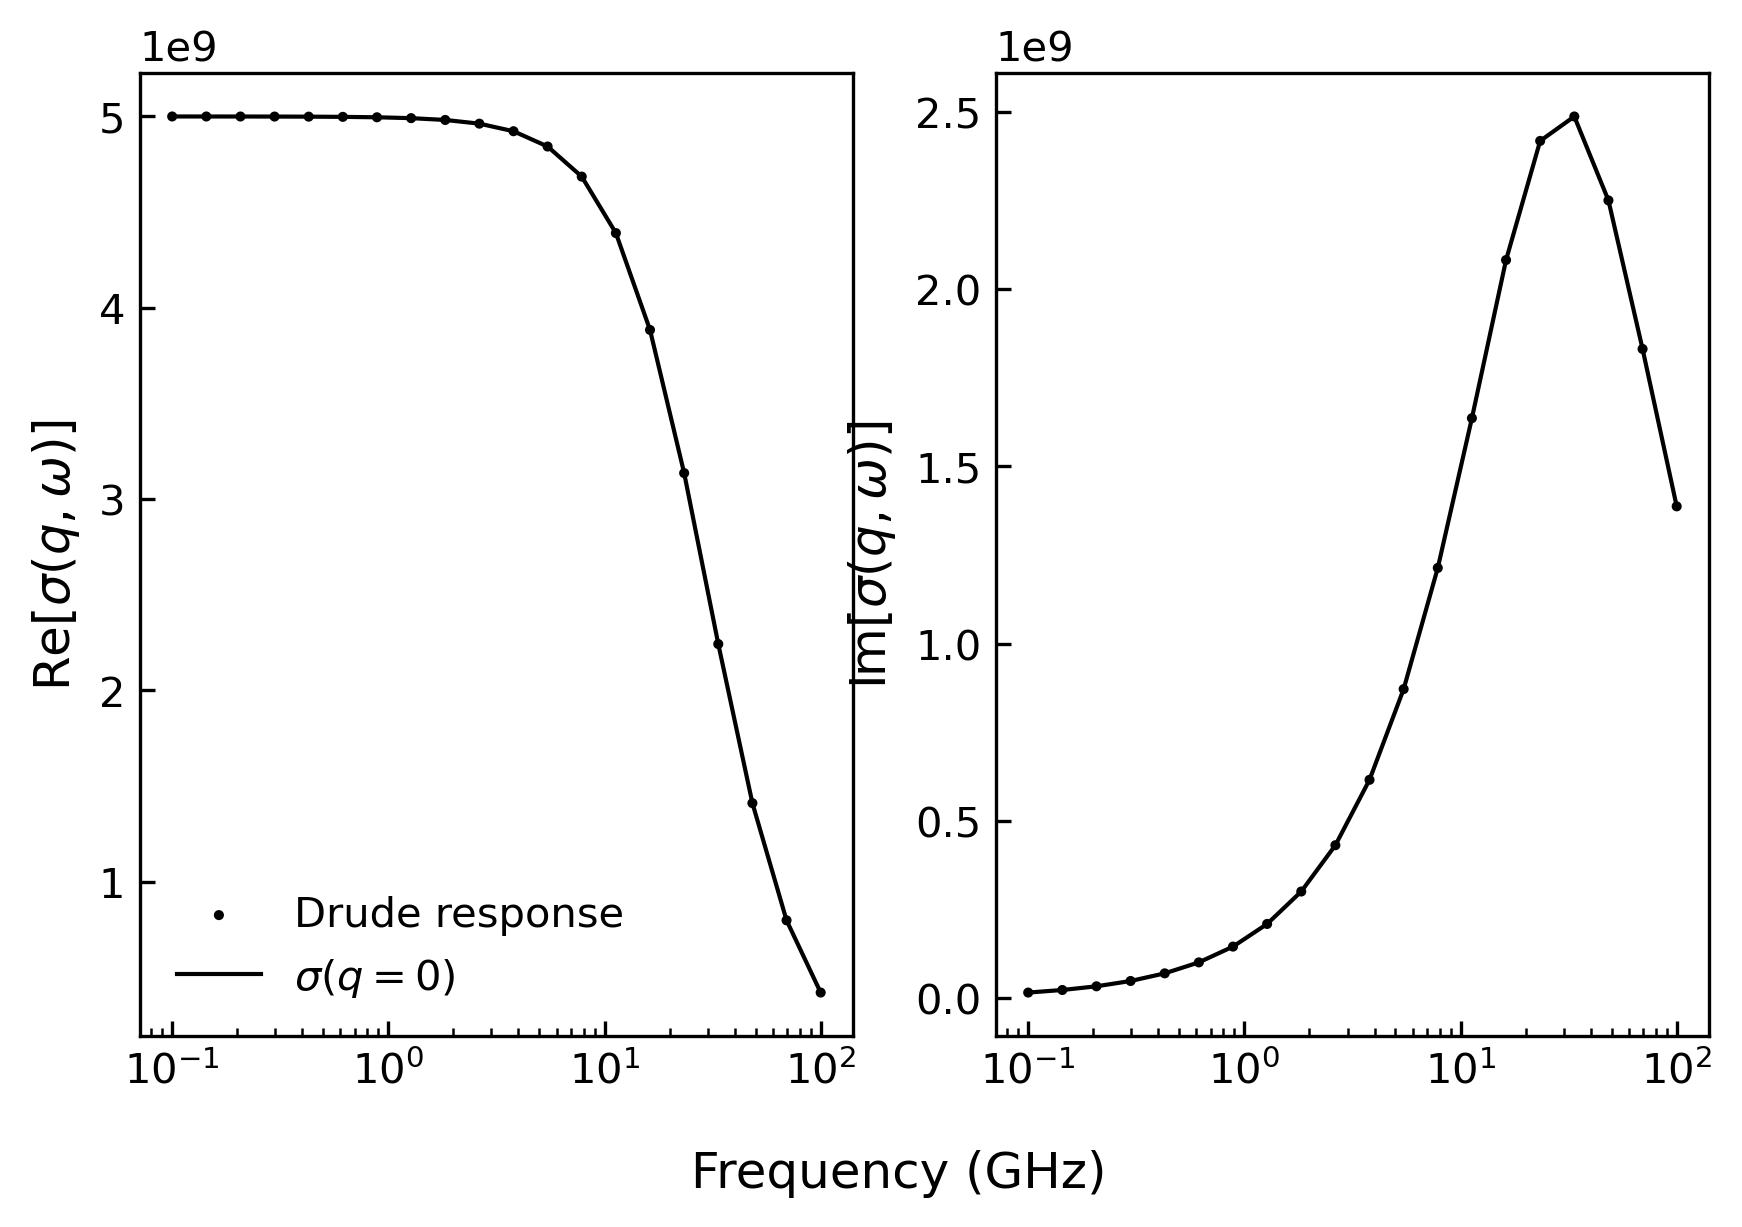

In [31]:
cond_relaxation = (resistivity_residual)**-1 / (1 - 1j * omega_analytic / gamma_MR_analytic)

cond_spectra_3D_q0_limit = cond_spectra_3D_isotropic[0,:]

cond_error = (cond_spectra_3D_q0_limit - cond_relaxation)/cond_relaxation

print(cond_spectra_3D_q0_limit.shape)

freqs_plot = freqs_analytic/GHz
y_plot1 = cond_relaxation
y_plot2 = cond_spectra_3D_q0_limit

fh.set_plot_template('2ColWide')
fig, (ax1, ax2) = plt.subplots(1, 2)

# ax.plot([], [], alpha=0, label = string_gamma_l)
ax1.scatter(freqs_plot, y_plot1.real, color='k', s=2, linestyle='', label='Drude response')
ax1.plot(freqs_plot, y_plot2.real, color='k', label=r'$\sigma(q=0)$')

ax2.scatter(freqs_plot, y_plot1.imag, color='k', s=2, linestyle='', label='Drude response')
ax2.plot(freqs_plot, y_plot2.imag, color='k', label=r'$\sigma(q=0)$')

ax1.set_ylabel(r'Re$[\sigma(q,\omega)]$')
ax2.set_ylabel(r'Im$[\sigma(q,\omega)]$')

fig.suptitle(label_f_GHz, y=0.02, ha='center')

for ax in [ax1, ax2]:
    ax.set_xscale('log')


ax1.set_xscale('log')
# ax1.set_yscale('log')

# ax1.axvline(gamma_MR_analytic, color='k', linestyle='dotted', label=r'$\gamma_{MR}$')

ax1.legend()

# figure_filename = FS_model + f'_Hein_Xs_BakerScale{figure_name_suffix}.svg'
# figure_filepath = os.path.join(figure_directory, figure_filename)
# fh.save_svg(figure_filepath)

plt.show()

## Plot the error in the q=0

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<Figure size 2025x1251.55 with 0 Axes>

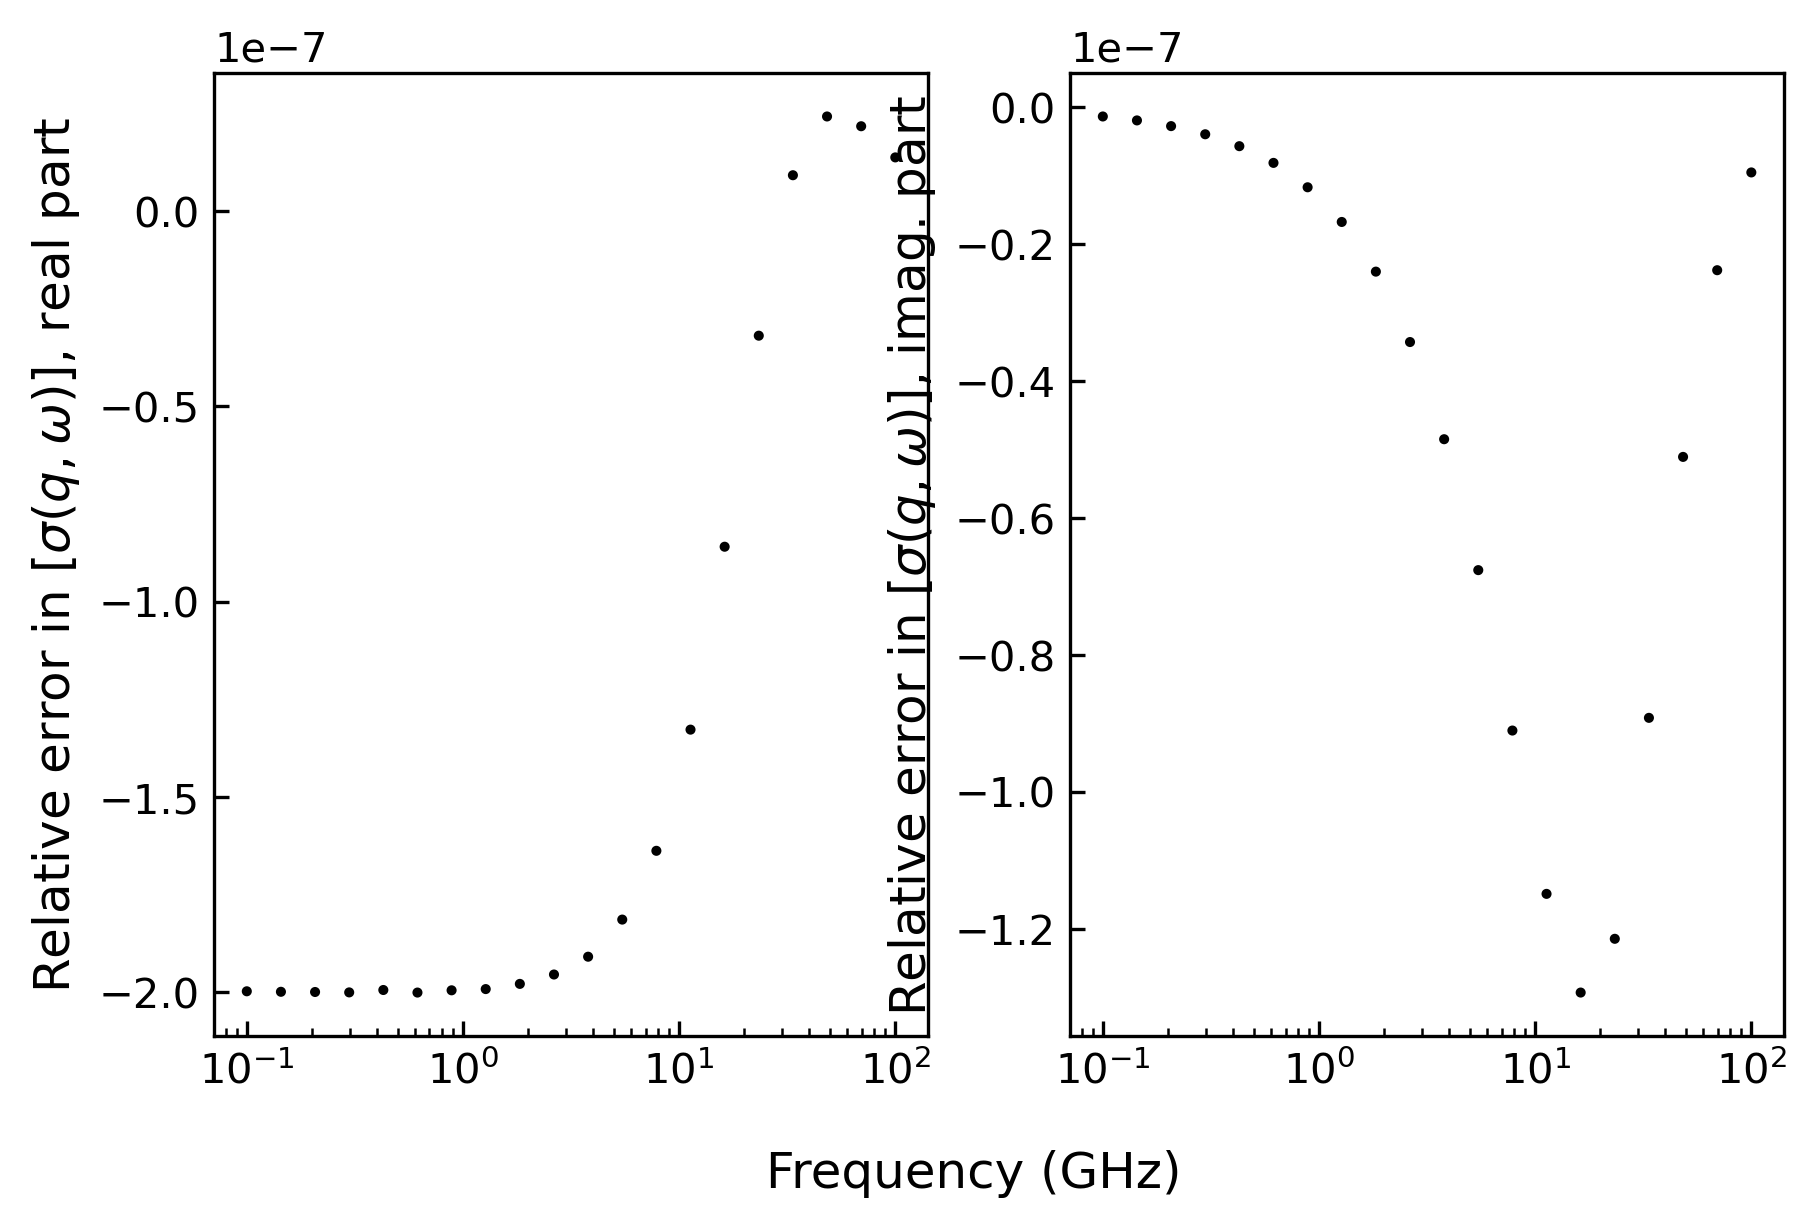

In [32]:
fh.set_plot_template('2ColWide')
fig, (ax1, ax2) = plt.subplots(1, 2)

y_plot = cond_error

# ax.plot([], [], alpha=0, label = string_gamma_l)
ax1.scatter(freqs_plot, y_plot.real, color='k', s=2, linestyle='')
ax2.scatter(freqs_plot, y_plot.imag, color='k', s=2, linestyle='')

ax1.set_ylabel(r'Relative error in $[\sigma(q,\omega)]$, real part')
ax2.set_ylabel(r'Relative error in $[\sigma(q,\omega)]$, imag. part')

# fig.suptitle(label_f_GHz, y=0.02, ha='center')

for ax in [ax1, ax2]:
    ax.set_xscale('log')


ax1.set_xscale('log')
# ax1.set_yscale('log')

# ax1.axvline(gamma_MR_analytic, color='k', linestyle='dotted', label=r'$\gamma_{MR}$')

fig.suptitle(label_f_GHz, y=0.02, ha='center')

ax1.legend()

# figure_filename = FS_model + f'_Hein_Xs_BakerScale{figure_name_suffix}.svg'
# figure_filepath = os.path.join(figure_directory, figure_filename)
# fh.save_svg(figure_filepath)

plt.show()

## Plot the estimated plasma frequency and fermi velocity from the high-q conductivity(q) fits

For the limit of $q \ell_{MR} \gg 1$, we can extract the Fermi velocity and plasma frequency from the conductivity:
 
$$v_F = \frac{A}{B}$$
$$\omega_{plasma} = \frac{A}{v_F}$$
 
where:
$$A =  \frac{\epsilon_0\omega_{p}^2}{v_F} = \frac{4}{3\pi} \Re(\sigma(q_0,\omega_0)) q_0$$
$$B =  \frac{\epsilon_0\omega_{p}^2}{v_F^2} = \frac{\Im(\sigma(q_0,\omega_0)) q_0^2}{3\omega_0}$$

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


100.0


<Figure size 2025x1251.55 with 0 Axes>

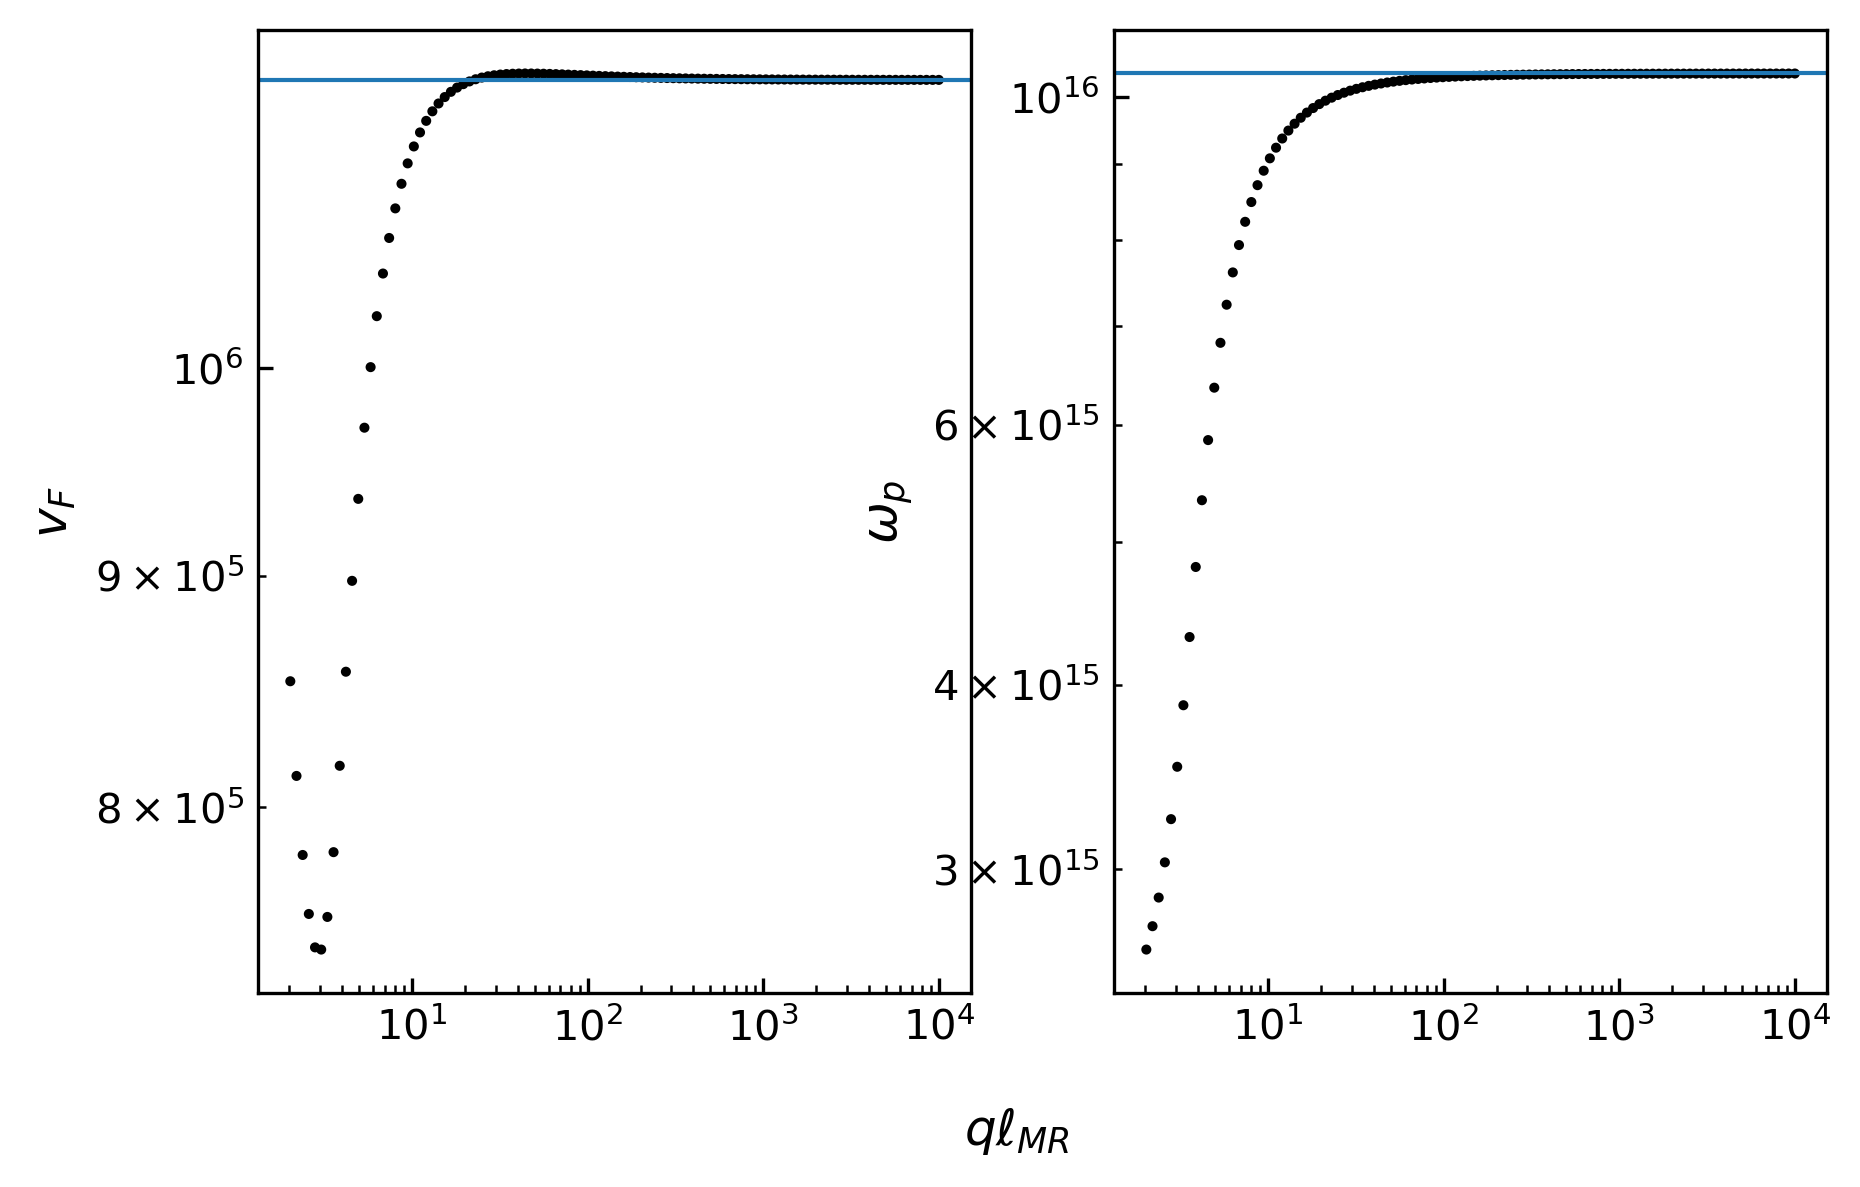

In [34]:
i_freq = -1
freq_plot = freqs_analytic[i_freq]
omega_plot = 2*pi*freq_plot
print(freq_plot/GHz)

v_F_cond_calc, freq_plasma_cond_calc, _, _ = et.conductivity_spectrum_Fermi_surface_properties(q_analytic, omega_plot, cond_spectra_3D_isotropic[:, i_freq])

filter_x_plot = (ql >= 2)

x_plot = ql[filter_x_plot]
y_plot1 = (v_F_cond_calc)[filter_x_plot]
y_plot2 = (freq_plasma_cond_calc)[filter_x_plot]


fh.set_plot_template('2ColWide')
fig, (ax1, ax2) = plt.subplots(1, 2)

# ax.plot([], [], alpha=0, label = string_gamma_l)
ax1.scatter(x_plot, y_plot1, color='k', s=2, linestyle='')
ax1.axhline(v_F_analytic)

ax2.scatter(x_plot, y_plot2, color='k', s=2, linestyle='')
ax2.axhline(freq_plasma_analytic)

ax1.set_ylabel(r'$v_F$')
ax2.set_ylabel(r'$\omega_{p}$')

# fig.suptitle(label_f_GHz, y=0.02, ha='center')

for ax in [ax1, ax2]:
    ax.set_xscale('log')
    ax.set_yscale('log')

fig.suptitle(r'$q \ell_{MR}$', y=0.02, ha='center')

# ax1.axvline(gamma_MR_analytic, color='k', linestyle='dotted', label=r'$\gamma_{MR}$')

ax1.legend()
ax2.legend()

# figure_filename = FS_model + f'_Hein_Xs_BakerScale{figure_name_suffix}.svg'
# figure_filepath = os.path.join(figure_directory, figure_filename)
# fh.save_svg(figure_filepath)

plt.show()

## Plot the conductivity spectrum at the highest frequency

For the limit of $q \ell_{MR} \gg 1$ the real and imaginary parts of the conductivity spectrum are:

$$\Re(\sigma_\omega) = \sigma_{DC} \frac{3\pi}{4}\left(\frac{1}{q\ell_{\text{MR}}}\right)^1$$
$$\Im(\sigma_\omega) = \sigma_{DC} 3 \frac{\omega}{\gamma_{\text{MR}}}\left(\frac{1}{q\ell_{\text{MR}}}\right)^2$$

100.0
(400,)
(178,)
(178,)


<Figure size 2025x1251.55 with 0 Axes>

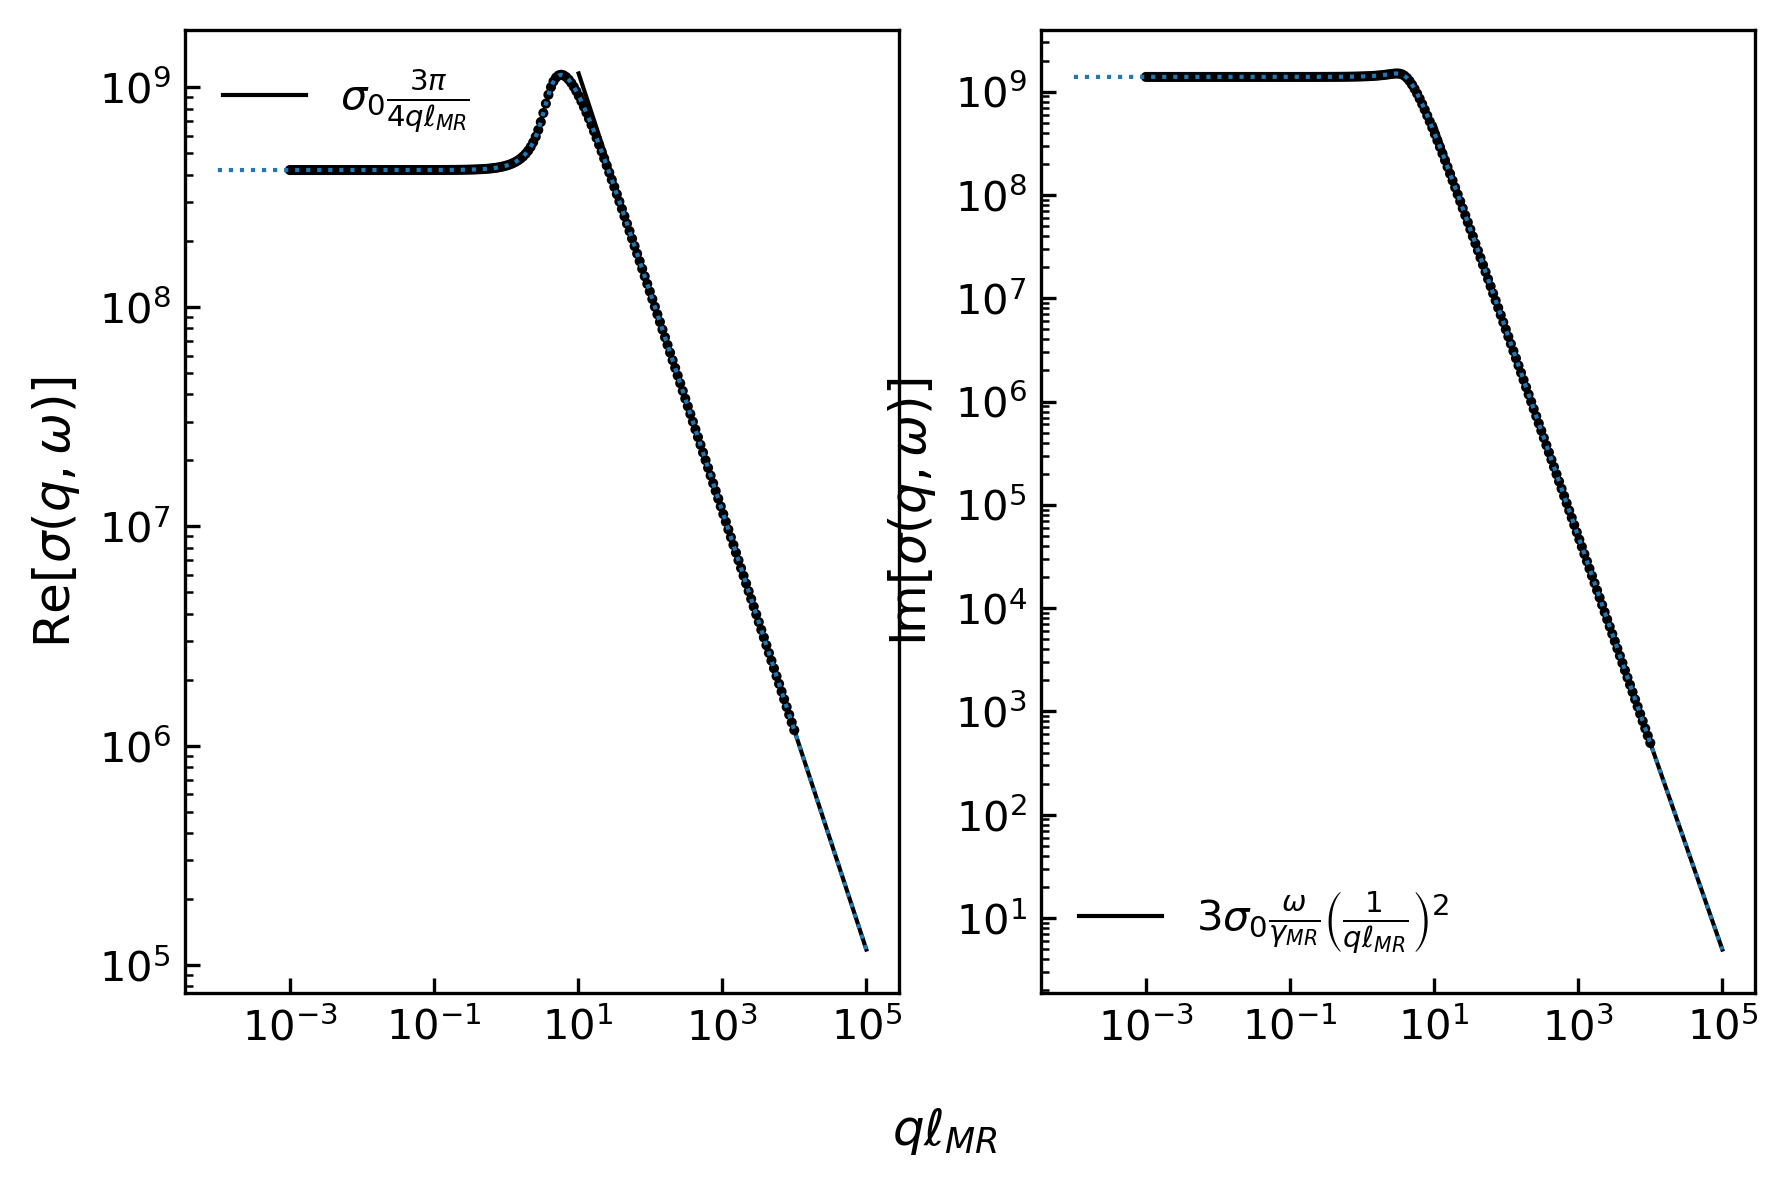

In [35]:
i_freq = -1

freq_plot = freqs_analytic[i_freq]
omega_plot = 2*pi*freq_plot
print(freq_plot/GHz)

# print(cond_relaxation[i_freq].shape)

# cond_spectra_3D_isotropic_high_q_real = np.multiply(cond_relaxation,(3*pi/(4*q_prime)))[:,i_freq]
# cond_spectra_3D_isotropic_high_q_real = np.multiply(cond_relaxation,(3*pi/(4*q_prime)) - 2/q_prime**2)[:,-1]

# cond_spectra_3D_isotropic_high_q_imag = np.multiply(cond_relaxation[i_freq],(10/2)*(omega_plot/gamma_MR_analytic)*ql**-2)
# cond_spectra_3D_isotropic_high_q_imag = np.multiply(cond_relaxation[i_freq],(3)*(omega_plot/gamma_MR_analytic)*(2 + (omega_plot/gamma_MR_analytic)**2)*ql**-2)
# cond_spectra_3D_isotropic_high_q_imag = np.multiply(cond_relaxation[i_freq],(3/2)*(0.5*pi/q_prime -2/q_prime**2))[:,i_freq]

cond_spectra_3D_isotropic_high_q_complex = et.cond_spectra_3D_isotropic_high_q_complex(ql_interp, freq_plot, resistivity_residual, freq_plasma_analytic)
# cond_spectra_3D_isotropic_high_q_real = np.multiply(resistivity_residual**-1,(3*pi/(4*ql_interp)))
# cond_spectra_3D_isotropic_high_q_imag = 1j*np.multiply(resistivity_residual**-1,3*(omega_plot/gamma_MR_analytic)*ql_interp**-2)

# sigma_interp_func = gen_sigma_interp_func())


sigma_interp_func_theory_extrapolate = imp.gen_sigma_interp_func_theory_extrapolate(q_analytic,cond_spectra_3D_isotropic[:,i_freq])


print(cond_spectra_3D_isotropic_high_q_complex.shape)

filter_y_plot2 = (ql_interp >= 10)

x_plot = ql
y_plot1 = (cond_spectra_3D_isotropic[:,i_freq])

x_plot_2 = ql_interp[filter_y_plot2]
y_plot2 = (cond_spectra_3D_isotropic_high_q_complex.real)[filter_y_plot2]
x_plot_3 = ql_interp[filter_y_plot2]
y_plot3 = (cond_spectra_3D_isotropic_high_q_complex.imag*1j)[filter_y_plot2]
print(y_plot2.shape)
print(y_plot3.shape)

fh.set_plot_template('2ColWide')
fig, (ax1, ax2) = plt.subplots(1, 2)

# ax.plot([], [], alpha=0, label = string_gamma_l)
ax1.scatter(x_plot, y_plot1.real, color='k', s=2, linestyle='')
# ax1.plot(x_plot_2, y_plot2.real, color='k', label=r'$\Re(\sigma_\omega \frac{3 \pi}{4 q\prime})$')
ax1.plot(x_plot_2, y_plot2.real, color='k', label=r'$\sigma_0 \frac{3 \pi}{4 q \ell_{MR}}$')

## New interpolation func
ax1.plot(ql_interp,sigma_interp_func_theory_extrapolate(q_interp, freq_plot).real, linestyle='dotted')

ax2.scatter(x_plot, y_plot1.imag, color='k', s=2, linestyle='')
# ax2.plot(x_plot_3, y_plot3.imag, color='k', label=r'$\frac{3}{2} \frac{\omega}{\gamma_{MR}} \left(\frac{1}{q \ell_{MR}}\right)^2$')
ax2.plot(x_plot_3, y_plot3.imag, color='k', label=r'$3 \sigma_0 \frac{\omega}{\gamma_{MR}} \left(\frac{1}{q \ell_{MR}}\right)^2$')

ax2.plot(ql_interp,sigma_interp_func_theory_extrapolate(q_interp, freq_plot).imag, linestyle='dotted')

ax1.set_ylabel(r'Re$[\sigma(q,\omega)]$')
ax2.set_ylabel(r'Im$[\sigma(q,\omega)]$')

# fig.suptitle(label_f_GHz, y=0.02, ha='center')

for ax in [ax1, ax2]:
    ax.set_xscale('log')
    ax.set_yscale('log')

fig.suptitle(r'$q \ell_{MR}$', y=0.02, ha='center')

# ax1.axvline(gamma_MR_analytic, color='k', linestyle='dotted', label=r'$\gamma_{MR}$')

ax1.legend()
ax2.legend()

# figure_filename = FS_model + f'_Hein_Xs_BakerScale{figure_name_suffix}.svg'
# figure_filepath = os.path.join(figure_directory, figure_filename)
# fh.save_svg(figure_filepath)

plt.show()

# Calculate the analytic surface impedance for both kinds of surface scattering
Using the conductivity spectra interpolation and extrapolation functions, which save time.

In [36]:

Zs_interp_isotropic = imp.Z_interp_func(q_analytic, omega_analytic, cond_spectra_3D_isotropic, surface_scattering='specular')
print(Zs_interp_isotropic.shape)
Zd_interp_isotropic = imp.Z_interp_func(q_analytic, omega_analytic, cond_spectra_3D_isotropic, surface_scattering='diffuse')

(20,)


## Calculate the analytic surface impedance for both kinds of surface scattering
Using the full conductivity spectra formulas.
This way takes far more time, and can be skipped. These are used for comparison to verify the interpolated calculation agrees.

In [37]:
# def cond_spectrum_3D_isotropic_func(q, omega):
#     ## It was giving results in arrays to the later functions, which they did not like. Forcing it to give scalars.
#     return et.cond_spectrum_3D_isotropic(q, omega, l_MR_analytic, gamma_MR_analytic, resistivity_residual)[0][0]

## Hein, Ormeno, and Gough function
# Zs_isotropic = imp.Zs_func(omega_analytic, cond_spectrum_3D_isotropic_func, maxdegree=10)
# print(Zs_isotropic)
# Zd_isotropic = imp.Zd_func(omega_analytic, cond_spectrum_3D_isotropic_func, maxdegree=10)

# Calculate analytic limits of different surface impedance limits
From Graham's thesis page 21

In [38]:
Z_limits = et.get_skin_effect_regime_limits(freqs_analytic, resistivity_residual, freq_plasma_analytic, v_F_analytic, gamma_MR_analytic)

Z_CSE = Z_limits["CSE"]
Z_ASE_specular = Z_limits["ASE (specular surface scattering)"]
Z_ASE_diffuse = Z_limits["ASE (diffuse surface scattering)"]
Z_relaxation = Z_limits["Relaxation"]
Z_relaxation_full = Z_limits["Local transport (Drude response)"]

# Plot the $Z_s$ spectra

## $R_s(f)$ Baker plot

0.002896194509706679


<Figure size 2025x1251.55 with 0 Axes>

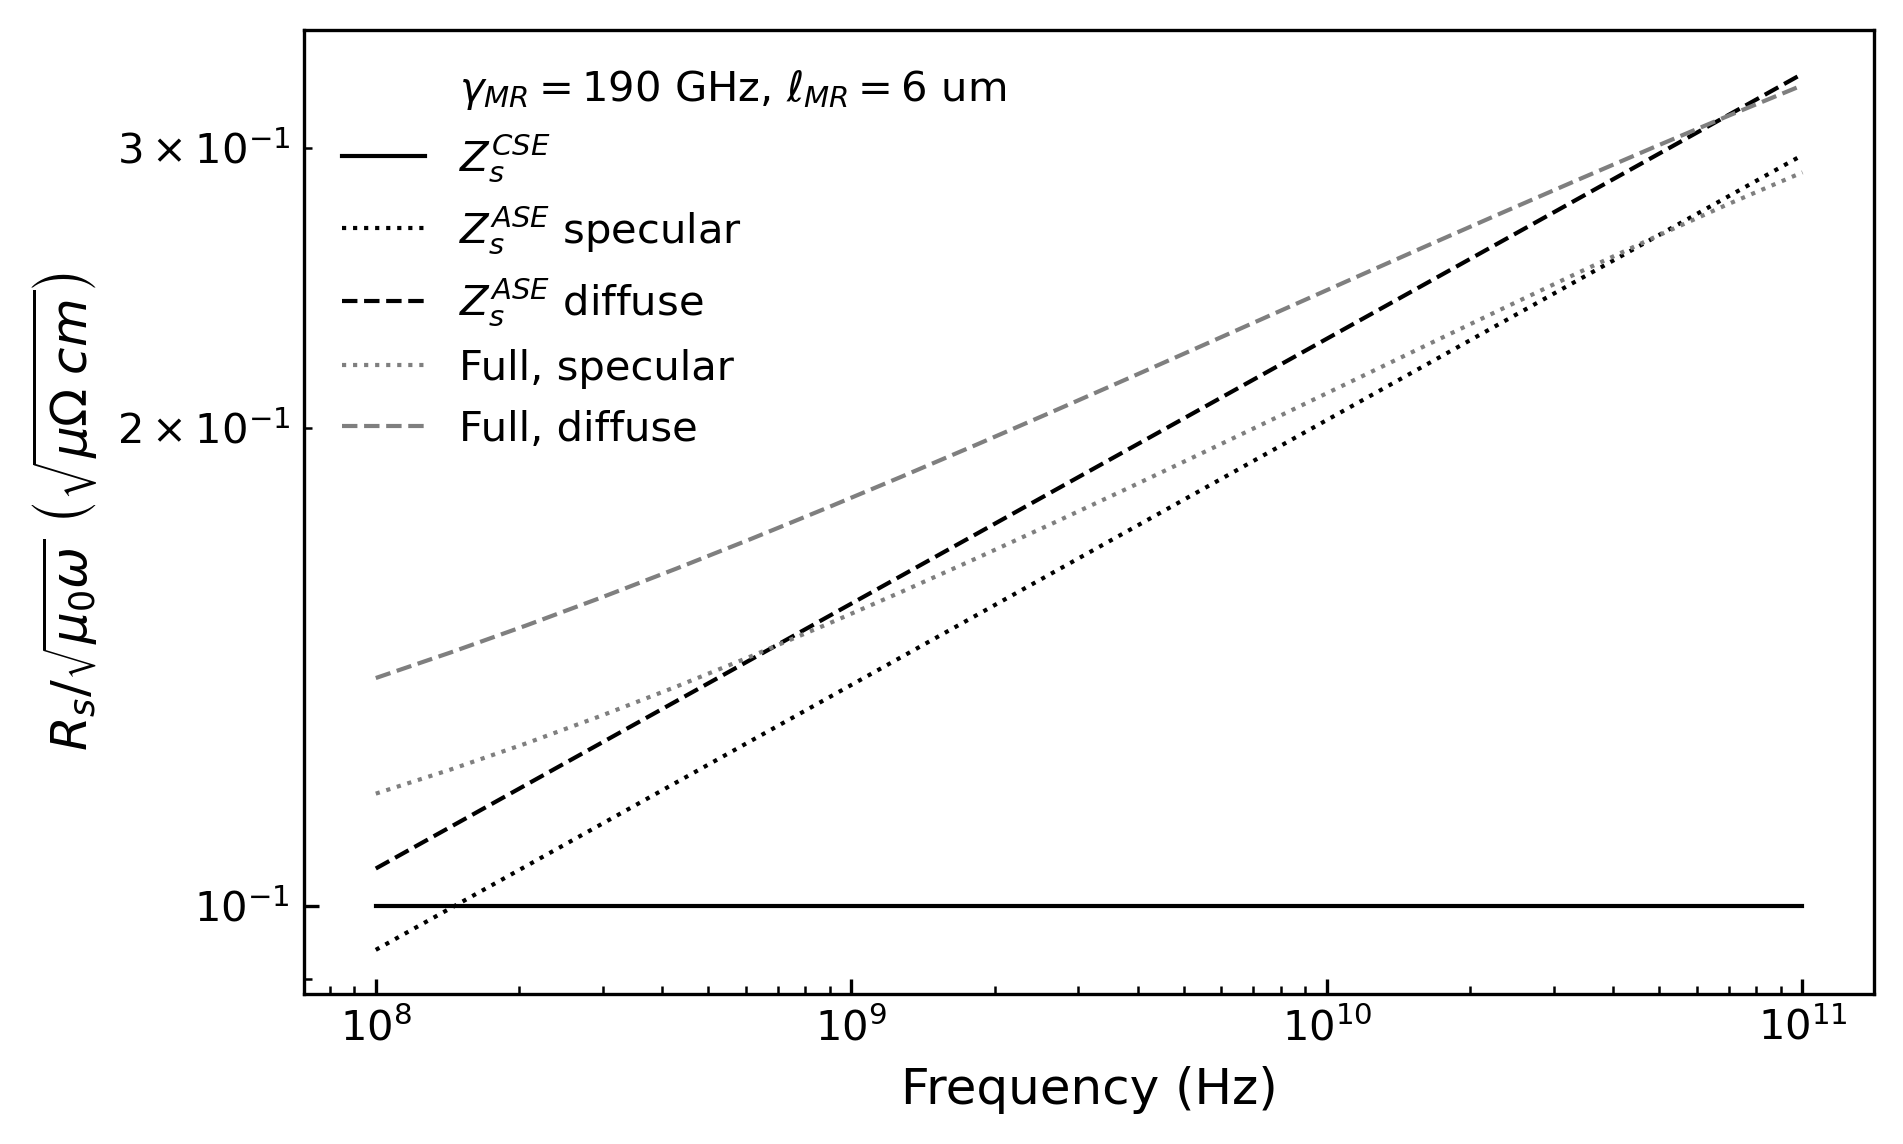

In [44]:
##TODO: move these to a library
label_Zs_CSE = r'$Z_s^{CSE}$'
label_Zs_ASE = r'$Z_s^{ASE}$'
label_Zs_ASE_diff = r'$Z_s^{ASE}$ diffuse'
label_Zs_ASE_spec = r'$Z_s^{ASE}$ specular'
label_Zs_relax = r'$Z_s^{Relax}$'
label_Zs_full = r'$Z_s$ Full $\sigma(q,\omega)$'
label_Zs_interp = r'$Z_s$ Interpolated $\sigma(q,\omega)$'

freqs_plot = freqs_analytic
Baker_scale = bb.Baker_scale(freqs_plot/GHz)

# Rs.

# Rs_spec_full = Zs_isotropic.real
# Rs_spec_interp = Zs_interp_isotropic.real
# Rs_diffuse_interp = Zd_interp_isotropic.real

absorptivity = (3/4)*(v_F_analytic/c)
print(absorptivity)
Z_vacuum = np.sqrt(mu_0/epsilon_0)

##TODO: move this to the library
Rs_relaxation_limit = mu_0*depth_London*gamma_MR_analytic/2
Rs_anomalous_reflection_diffuse_limit = mu_0*depth_London*((3/4)*v_F_analytic/(2*depth_London) + gamma_MR_analytic)/2
# Rs_anomalous_reflection_diffuse_limit = Rs_relaxation_limit*(3/4)*(v_F_analytic/c)
# Rs_anomalous_reflection_diffuse_limit = Rs_relaxation_limit*(3/2)*(omega_analytic*depth_London/v_F_analytic)**2

## Baker plot - real part
fh.set_plot_template('2ColWide')
fig, ax = plt.subplots()

ax.plot([], [], alpha=0, label = string_gamma_l)
ax.plot(freqs_plot, Z_CSE.real/Baker_scale, color='k', linestyle='solid', label=label_Zs_CSE)
ax.plot(freqs_plot, Z_ASE_specular.real/Baker_scale, color='k', linestyle='dotted', label=label_Zs_ASE_spec)
ax.plot(freqs_plot, Z_ASE_diffuse.real/Baker_scale, color='k', linestyle='dashed', label=label_Zs_ASE_diff)

# ax.plot(freqs_plot, Zs_isotropic.real/Baker_scale, color='k', linestyle='solid', label='Interp, spec.')
ax.plot(freqs_plot, Zs_interp_isotropic.real/Baker_scale, color=AgAu_color, linestyle='dotted', label='Full, specular')
# ax.plot(freqs_plot, Zd_isotropic.real/Baker_scale, color='k', linestyle='solid', label='Interp, spec.')
ax.plot(freqs_plot, Zd_interp_isotropic.real/Baker_scale, color=AgAu_color, linestyle='dashed', label='Full, diffuse')


# ax.plot(freqs_plot, Z_relaxation_full.real/Baker_scale, linestyle='dotted', label='Relaxation (full)')
# ax.plot(freqs_plot, Rs_relaxation_limit/Baker_scale, linestyle='dotted', label='Relaxation (limit)')
# ax.plot(freqs_plot, Rs_anomalous_reflection_diffuse_limit/Baker_scale, linestyle='dotted', label='Relaxation (limit)')



# ax.axvline(freq_C_to_A_Rs_specular, linestyle= 'dashed', color='k')
# ax.axvline(freq_A_to_EA, linestyle='dotted', color='k')
# ax.axvline(freq_relaxation, color='b')

ax.set_xlabel(label_f_Hz)
ax.set_ylabel(label_Rs_Baker)
ax.set_xscale('log')
ax.set_yscale('log')

# ax.set_xlim(0.1*GHz, 0.5*GHz)
# ax.set_xlim(0.1*GHz, 20*GHz)
# ax.set_ylim(bottom=0.95*(Z_CSE.real/Baker_scale)[0], top=1.05*(Z_CSE.real/Baker_scale)[0])

plt.legend()

# figure_filename = FS_model + f'_Hein_Xs_BakerScale{figure_name_suffix}.svg'
# figure_filepath = os.path.join(figure_directory, figure_filename)
# fh.save_svg(figure_filepath)

plt.show()

## $X_s(f)$ Baker plot

<Figure size 2025x1251.55 with 0 Axes>

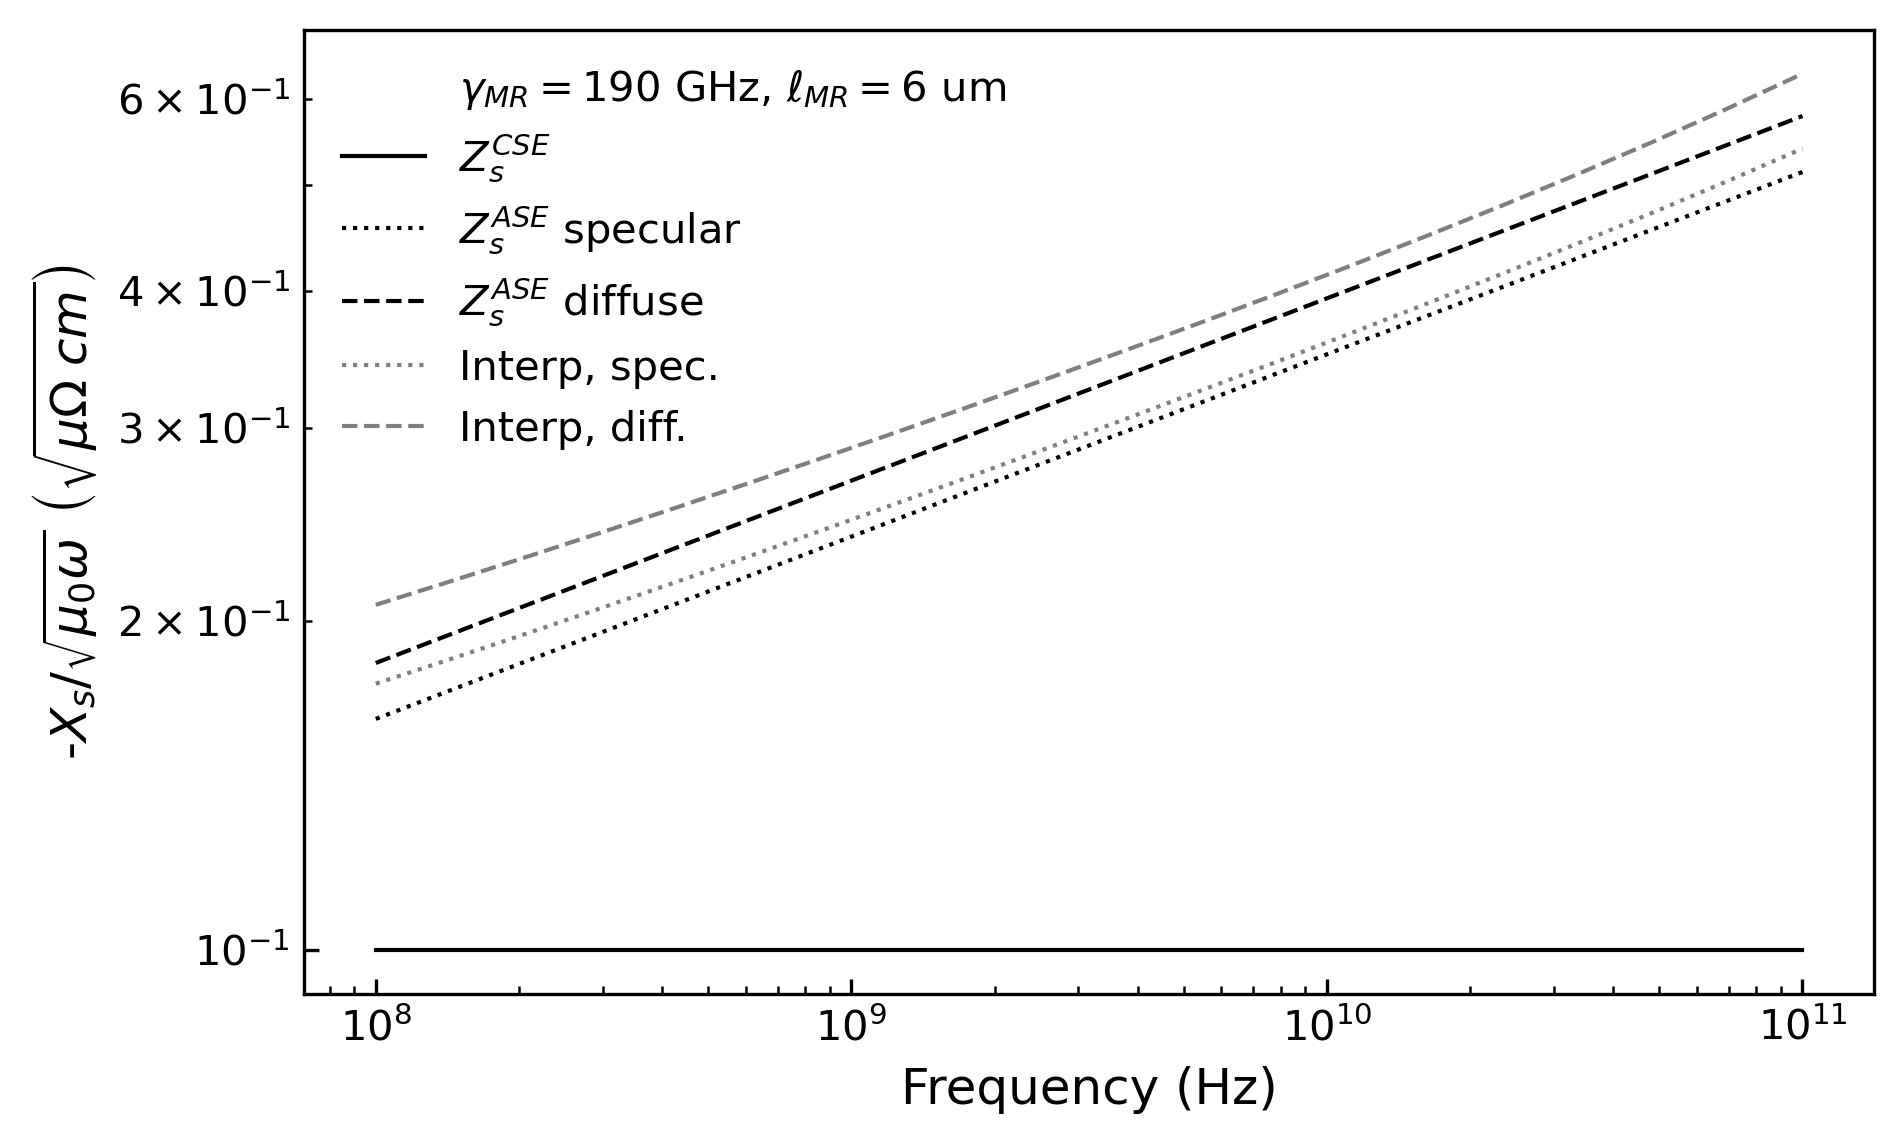

In [46]:
## Baker plot - imaginary part
fh.set_plot_template('2ColWide')
fig, ax = plt.subplots()

ax.plot([], [], alpha=0, label = string_gamma_l)
ax.plot(freqs_plot, -Z_CSE.imag/Baker_scale, color='k', linestyle='solid', label=label_Zs_CSE)
ax.plot(freqs_plot, -Z_ASE_specular.imag/Baker_scale, color='k', linestyle='dotted', label=label_Zs_ASE_spec)
ax.plot(freqs_plot, -Z_ASE_diffuse.imag/Baker_scale, color='k', linestyle='dashed', label=label_Zs_ASE_diff)

ax.plot(freqs_plot, -Zs_interp_isotropic.imag/Baker_scale, color=AgAu_color, linestyle='dotted', label='Interp, spec.')
ax.plot(freqs_plot, -Zd_interp_isotropic.imag/Baker_scale, color=AgAu_color, linestyle='dashed', label='Interp, diff.')
# ax.plot(freqs_plot, Rs_spec_full/Baker_scale, color='k', linestyle='solid', label='Full, spec.')
# ax.plot(freqs_plot, -Z_relaxation_full.imag/Baker_scale, linestyle='dotted', label='Relaxation (full)')
# ax.plot(freqs_plot, -Z_relaxation.imag/Baker_scale, linestyle='dotted', label='Relaxation (limit)')



# ax.axvline(freq_C_to_A_Rs_specular, color='r')
# ax.axvline(freq_relaxation, color='b')
# ax.axvline(freq_A_to_EA, color='k')

ax.set_xlabel(label_f_Hz)
ax.set_ylabel('-' + label_Xs_Baker)
ax.set_xscale('log')
ax.set_yscale('log')

# ax.set_xlim(0.1*GHz, 0.5*GHz)
# ax.set_xlim(0.1*GHz, 20*GHz)
# ax.set_ylim(bottom=0.95*(Z_CSE.real/Baker_scale)[0], top=1.05*(Z_CSE.real/Baker_scale)[0])

plt.legend()

# figure_filename = FS_model + f'_Hein_Xs_BakerScale{figure_name_suffix}.svg'
# figure_filepath = os.path.join(figure_directory, figure_filename)
# fh.save_svg(figure_filepath)

plt.show()